In [ ]:
from train_ga_mdm import *
from functools import partial

# normalize the lie algebra and check the normalization of a batch
from torch.utils.data import DataLoader
    # Optional Anomaly Detection (enable via env)
    # if os.getenv("TORCH_ANOMALY_DETECT", "0") == "1":
    #     torch.autograd.set_detect_anomaly(True)
num_steps = 60000
batch_size = 16
# data_path = "joints"
data_path = "test_data"
dataset = NPZDictDataset(data_path, keys=set(DIFFUSE_KEYS + ANSWER_KEYS), pred_len=1, context_len=32)
# ---for repeat sampling during debugging---
steps_per_epoch = 10
sampler = RandomSampler(dataset, replacement=True,
            num_samples=batch_size * steps_per_epoch)
batch_sampler = BatchSampler(sampler, batch_size=batch_size, drop_last=True)
# ---for repeat sampling during debugging---

loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=8, collate_fn=dict_array_collate_fn, pin_memory=True)
num_epochs = num_steps // batch_size
save_interval = 5000 // batch_size
model = ga_mdm()
opt = AdamW(
    # with amp, we don't need to use the mp_trainer's master_params
    model.parameters(),
    lr=1e-3,
    weight_decay=0.0,
    betas=(0.9, 0.999),
)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode='min',
    factor=0.9,
    patience=5,
    min_lr=1e-6,
)
schedule_sampler = UniformSampler(TOTAL_DIFFUSION_STEPS)
step = 0
fail_count = 0
LOG_EVERY_N = int(os.getenv("LOG_EVERY_N", "50"))
logger.info(f"Train steps: {num_steps}")
gen = iter(loader)
batch = next(gen)

2025-12-08 12:05:10,095 | INFO | train_utils | Train steps: 60000


In [7]:
torch.autograd.set_detect_anomaly(True)
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [1]:
from train_ga_mdm import *
from tqdm import tqdm
from torch.utils.data import DataLoader, RandomSampler, BatchSampler
from torch.utils.tensorboard import SummaryWriter
from functools import partial
num_steps = 20000
batch_size = 8
pred_len = 16
context_len = 32
fixed_length = context_len + pred_len
# data_path = "joints"
data_path = "test_data"
dataset = NPZDictDataset(data_path, keys=set(DIFFUSE_KEYS + ANSWER_KEYS), pred_len=pred_len, context_len=context_len)
# ---for repeat sampling during debugging---
steps_per_epoch = 10
sampler = RandomSampler(dataset, replacement=True,
            num_samples=batch_size * steps_per_epoch)
batch_sampler = BatchSampler(sampler, batch_size=batch_size, drop_last=True)
# ---for repeat sampling during debugging---
collate_fn = partial(dict_array_collate_fn, pred_len=pred_len)
loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=8, collate_fn=collate_fn, pin_memory=True)
num_epochs = num_steps // (batch_size*steps_per_epoch)
save_interval = 5000 // batch_size
model = ga_mdm(fixed_length=fixed_length, pred_len=pred_len)
opt = AdamW(
    # with amp, we don't need to use the mp_trainer's master_params
    model.parameters(),
    lr=1e-3,
    weight_decay=0.0,
    betas=(0.9, 0.999),
)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode='min',
    factor=0.98,
    patience=5,
    min_lr=1e-6,
)
schedule_sampler = UniformSampler(TOTAL_DIFFUSION_STEPS)
step = 0
fail_count = 0
LOG_EVERY_N = int(os.getenv("LOG_EVERY_N", "50"))
max_grad_norm = float(os.getenv("MAX_GRAD_NORM", "1.0"))
logger.info(f"Train steps: {num_steps}")

act_stats = None
gen = iter(loader)
batch, pred = next(gen)
step += 1
t, weights = schedule_sampler.sample(batch['batch_size'])
# TESTING: fixed noise level
# t = torch.ones(batch_size, dtype=torch.int64) * 5
batch, answers, diffuse_shapes, trajectory, prefix_tensors, lengths = model(batch, pred, t)

Loading BERT...


2025-12-11 06:33:40,866 | INFO | train_utils | Train steps: 20000


In [36]:
for k, v in prefix_tensors.items():
    if isinstance(v, torch.Tensor):
        print(f"Prefix tensor {k}: shape {v.shape}")

Prefix tensor root_motor: shape torch.Size([8, 39, 1, 8])
Prefix tensor log_acceleration_root_rotor: shape torch.Size([3, 37, 1, 8])
Prefix tensor log_acceleration_body_rotors: shape torch.Size([3, 37, 21, 8])
Prefix tensor body_rotors: shape torch.Size([4, 39, 21, 8])
Prefix tensor velocity_body_rotors: shape torch.Size([4, 38, 21, 8])
Prefix tensor acceleration_body_rotors: shape torch.Size([4, 37, 21, 8])
Prefix tensor log_velocity_body_rotors_0: shape torch.Size([3, 1, 21, 8])
Prefix tensor chained_body_rotors: shape torch.Size([8, 39, 21, 8])
Prefix tensor log_velocity_root_rotor_0: shape torch.Size([3, 1, 1, 8])
Prefix tensor log_body_rotors_0: shape torch.Size([3, 1, 21, 8])
Prefix tensor acceleration_root_motor: shape torch.Size([8, 37, 1, 8])
Prefix tensor velocity_root_motor: shape torch.Size([8, 38, 1, 8])
Prefix tensor log_velocity_root_translator_0: shape torch.Size([3, 1, 1, 8])
Prefix tensor log_acceleration_root_translator: shape torch.Size([3, 37, 1, 8])


In [37]:
for k, v in trajectory.items():
    print(f"Trajectory {k}: shape {v.shape}")

Trajectory log_acceleration_root_translator: shape torch.Size([3, 37, 1, 8])
Trajectory log_acceleration_root_rotor: shape torch.Size([3, 37, 1, 8])
Trajectory log_velocity_root_translator_0: shape torch.Size([3, 1, 1, 8])
Trajectory log_velocity_root_rotor_0: shape torch.Size([3, 1, 1, 8])
Trajectory log_acceleration_body_rotors: shape torch.Size([3, 37, 21, 8])
Trajectory log_velocity_body_rotors_0: shape torch.Size([3, 1, 21, 8])
Trajectory log_body_rotors_0: shape torch.Size([3, 1, 21, 8])
Trajectory acceleration_root_translator: shape (4, 37, 1, 8)
Trajectory acceleration_root_rotor: shape (4, 37, 1, 8)
Trajectory velocity_root_translator_0: shape (4, 1, 1, 8)
Trajectory velocity_root_rotor_0: shape (4, 1, 1, 8)
Trajectory acceleration_body_rotors: shape (4, 37, 21, 8)
Trajectory velocity_body_rotors_0: shape (4, 1, 21, 8)
Trajectory body_rotors_0: shape (4, 1, 21, 8)
Trajectory root_motor_1: shape (8, 1, 1, 8)
Trajectory root_motor: shape torch.Size([8, 37, 1, 8])
Trajectory velo

In [27]:
ANSWER_KEYS

['root_motor',
 'acceleration_root_motor',
 'velocity_root_motor',
 'body_rotors',
 'velocity_body_rotors',
 'acceleration_body_rotors',
 'chained_body_rotors']

In [30]:
lengths
lengths
# vectorized selection of prefix_tensors[k][:, idx-1, 0, b] for each batch b
pref = prefix_tensors[k]  # [blades, T, nodes, B]
inds = torch.tensor(lengths, device=pref.device) - 1  # [B]
p = pref.permute(3, 0, 1, 2)  # [B, blades, T, nodes]
# build index tensor for gather: [B, blades, 1, nodes]
idx = inds.view(-1, 1, 1, 1).expand(-1, p.shape[1], 1, p.shape[3])
sel = torch.gather(p, dim=2, index=idx).squeeze(2)[:, :, 0]  # [B, blades], node=0
# If you need the original list form:
result = [sel[b] for b in range(sel.shape[0])]
result

[tensor([ 0.9894, -0.0306,  0.0481,  0.0038, -0.1109,  0.0753,  0.0555, -0.0058]),
 tensor([ 0.9836, -0.0348,  0.0452, -0.0063, -0.0149,  0.0932, -0.1539,  0.0013]),
 tensor([ 9.8773e-01, -4.1656e-02,  3.9468e-02,  2.6018e-04,  1.4084e-01,
          2.5977e-02, -6.2214e-02,  1.6229e-03]),
 tensor([ 0.9935, -0.0319,  0.0474,  0.0026, -0.0845,  0.0710,  0.0259, -0.0044]),
 tensor([ 0.9890, -0.0316,  0.0473,  0.0033, -0.0911,  0.0982,  0.0635, -0.0070]),
 tensor([ 0.9245, -0.0265,  0.0451,  0.0200, -0.1442, -0.0135,  0.3527, -0.0126]),
 tensor([ 0.9890, -0.0316,  0.0473,  0.0033, -0.0911,  0.0982,  0.0635, -0.0070]),
 tensor([ 0.9896, -0.0416,  0.0393,  0.0048,  0.1385,  0.0180,  0.0333, -0.0014])]

In [ ]:
def extract_index_list(tensor, inds):
    pref = tensor  # [blades, T, nodes, B]
    p = pref.permute(3, 0, 1, 2)  # [B, blades, T, nodes]
    # build index tensor for gather: [B, blades, 1, nodes]
    idx = inds.view(-1, 1, 1, 1).expand(-1, p.shape[1], 1, p.shape[3])
    return torch.gather(p, dim=2, index=idx).squeeze(2)[:, :, 0]  # [B, blades], node=0

TRAJECTORY_KEYS = ['root_motor',
                   'velocity_root_motor'
                   'body_rotors',
                   'velocity_body_rotors']

trajectory = {}
for k in TRAJECTORY_KEYS:
    offset = 0
    if 'velocity' in k:
        offset = 1
    inds = torch.tensor(lengths, device=pref.device) - 1 - offset  # [B]
    trajectory = extract_index_list(prefix)


tensor([[ 9.8942e-01, -3.0638e-02,  4.8052e-02,  3.7796e-03, -1.1090e-01,
          7.5320e-02,  5.5513e-02, -5.8006e-03],
        [ 9.8357e-01, -3.4803e-02,  4.5206e-02, -6.2625e-03, -1.4869e-02,
          9.3155e-02, -1.5395e-01,  1.2606e-03],
        [ 9.8773e-01, -4.1656e-02,  3.9468e-02,  2.6018e-04,  1.4084e-01,
          2.5977e-02, -6.2214e-02,  1.6229e-03],
        [ 9.9355e-01, -3.1949e-02,  4.7415e-02,  2.6248e-03, -8.4539e-02,
          7.1035e-02,  2.5946e-02, -4.4477e-03],
        [ 9.8895e-01, -3.1602e-02,  4.7291e-02,  3.3174e-03, -9.1077e-02,
          9.8241e-02,  6.3494e-02, -7.0323e-03],
        [ 9.2447e-01, -2.6474e-02,  4.5134e-02,  1.9998e-02, -1.4417e-01,
         -1.3498e-02,  3.5268e-01, -1.2559e-02],
        [ 9.8895e-01, -3.1602e-02,  4.7291e-02,  3.3174e-03, -9.1077e-02,
          9.8241e-02,  6.3494e-02, -7.0323e-03],
        [ 9.8964e-01, -4.1587e-02,  3.9252e-02,  4.8310e-03,  1.3850e-01,
          1.8010e-02,  3.3313e-02, -1.4381e-03]])

In [ ]:
lengths

[36, 39, 6, 18, 13, 16, 12, 18]

In [39]:
k = 'velocity_body_rotors'
(trajectory[k][32, 0, 0].values()),  prefix_tensors[k][:, 34, 0, 0]

(tensor([ 0.9999, -0.0135,  0.0039, -0.0025], device='cuda:0'),
 tensor([ 1.0000, -0.0061,  0.0013, -0.0054]))

In [ ]:
# loss computation


In [93]:
trajectory['body_rotors_1'][:5, 0, 0].values()

[tensor([0.9885], device='cuda:0'),
 tensor([0.0015], device='cuda:0'),
 tensor([0.0265], device='cuda:0'),
 tensor([0.1486], device='cuda:0')]

In [32]:
alg.multivector(keys=KEY_MAP[k.replace('_0', '')], values=answers[k])[:, 0, 0]

(tensor([0.9997, 0.9997, 0.9992, 0.9987, 0.9991, 0.9993, 0.9996, 0.9999, 0.9999,
        0.9998, 0.9998, 0.9998, 0.9998, 0.9998, 0.9997, 0.9997])) + (tensor([-1.4598e-02, -7.8026e-03, -2.1767e-03,  6.9114e-04,  7.6735e-05,
        -2.2361e-03, -3.0977e-03, -4.5683e-03, -6.8119e-03, -8.6038e-03,
        -9.9224e-03, -1.0969e-02, -1.1835e-02, -1.2083e-02, -1.2371e-02,
        -1.2280e-02])) 𝐞₀₁ + (tensor([-2.4712e-03, -3.3061e-03, -2.7658e-03, -2.3629e-03, -2.0656e-03,
         3.2146e-05,  1.1971e-03,  1.7290e-03,  1.5919e-03,  7.8171e-04,
         3.1715e-05, -5.0976e-05,  1.2743e-04,  4.1841e-05,  7.6137e-05,
         1.3401e-04])) 𝐞₀₂ + (tensor([0.0011, 0.0023, 0.0043, 0.0063, 0.0056, 0.0027, 0.0006, 0.0005, 0.0016,
        0.0028, 0.0043, 0.0056, 0.0063, 0.0061, 0.0055, 0.0048])) 𝐞₀₃ + (tensor([-1.4577e-02, -6.4880e-03, -1.4969e-03,  3.7228e-05,  8.1802e-03,
         1.4797e-02,  1.0753e-02,  9.1862e-03,  7.1234e-03,  5.1136e-03,
         2.4235e-03,  1.3222e-03, -9.9776e-05, -1.713

In [55]:
lie = trajectory['log_acceleration_root_rotor']

In [56]:
rotors = rot_exp(lie)

In [58]:
rotors

(tensor([[[1.0000, 1.0000, 1.0000, 0.9999, 1.0000, 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000, 1.0000, 0.9999, 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000, 1.0000, 0.9999, 1.0000, 1.0000, 1.0000]],

        [[1.0000, 0.9999, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],

        [[0.9999, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9999, 1.0000]],

        [[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],

In [60]:
from amass_motor_utils import rotor_log
def rotor_log(R, tol=1e-8):
    blade = R.grade(2)
    signature = (blade**2).e
    norm = torch.sqrt(abs(signature))
    norm[norm < tol] = 1.0
    if torch.any(R.e > 1 + 1e-12) or torch.any(R.e < -1 - 1e-12):
        raise ValueError("Input to arccos is outside [-1,1] by more than tolerance.")
    return torch.arccos(torch.clamp(R.e, -1.0, 1.0)) * blade/norm

simple_log = rotor_log(rotors)


In [ ]:
(answers['chained_body_rotors'])[:, 0, 0]

tensor([[ 9.2464e-01,  9.0806e-01,  9.4781e-01,  9.5717e-01,  9.5480e-01,
          9.5405e-01,  9.8586e-01,  9.7422e-01,  9.4842e-01,  9.8586e-01,
          9.7422e-01,  9.4606e-01,  9.0890e-01,  9.5154e-01,  9.1940e-01,
          6.9509e-01,  9.7808e-01,  7.0585e-01,  9.9193e-01,  6.8798e-01,
          9.7899e-01],
        [-2.6594e-02,  2.8272e-02,  6.3006e-04, -8.7092e-02,  8.1553e-02,
          1.0956e-03, -5.5613e-02,  5.7585e-02,  1.2290e-03, -7.5314e-02,
          7.3339e-02, -2.7782e-03,  1.8038e-02,  1.2856e-02,  2.0643e-04,
          5.4191e-02,  5.4682e-02, -3.0294e-02,  1.8956e-01, -1.1471e-01,
          3.0396e-01],
        [ 4.5064e-02,  4.1825e-02, -4.5450e-02,  1.3367e-01,  1.1635e-01,
         -1.0633e-01,  3.2620e-01,  3.0067e-01, -1.2556e-01,  3.5731e-01,
          3.3525e-01, -2.3128e-01, -1.8887e-01, -1.9106e-01, -2.5863e-01,
         -1.8607e-01, -2.0122e-01, -1.0513e-01, -1.5876e-01, -3.1044e-02,
         -1.6645e-01],
        [ 1.9857e-02,  1.9638e-02,  2.6790e

In [5]:
for k, v in answers.items():
    print(k, v.shape)

root_motor torch.Size([8, 16, 1, 8])
acceleration_root_motor torch.Size([8, 16, 1, 8])
velocity_root_motor torch.Size([8, 16, 1, 8])
body_rotors torch.Size([4, 16, 21, 8])
velocity_body_rotors torch.Size([4, 16, 21, 8])
acceleration_body_rotors torch.Size([4, 16, 21, 8])
chained_body_rotors torch.Size([8, 16, 21, 8])


In [39]:
from data_loader import _apply_identity_padding
import warnings
def dict_array_collate_fn(batch, pred_len=0):
    """
    Pads and batches a list of dictionaries containing PyTorch tensors.
    
    Args:
        batch (list): A list of samples, where each sample is a dictionary 
                      with tensor values.
    
    Returns:
        dict: A single dictionary with batched/padded tensors.
    """
    # Filter out None samples to avoid DataLoader errors
    valid_batch = [item for item in batch if item is not None]
    dropped = len(batch) - len(valid_batch)
    if dropped > 0:
        print(f"dict_array_collate_fn: dropped {dropped} invalid sample(s) (None).")
    batch = valid_batch
    # Check if the batch is empty
        # Check if the batch is empty after filtering
    if not batch:
        warnings.warn("dict_array_collate_fn: empty batch after filtering invalid samples.")
        return {}

    # Get all keys from the first dictionary (assuming all samples have the same keys)
    keys = batch[0].keys()
    
    # Initialize the container for the batched result
    batched_data = {"lengths": {}, 'batch_size': len(batch)}
    pred_data = {} if pred_len > 0 else None
    
    for key in keys:
        # 1. Extract all values for the current key across all samples
        data_list = [item[key] for item in batch]
        # 2. Check the data type for the current key
        if isinstance(data_list[0], torch.Tensor):
            # Pad the sequences to the length of the longest one in this batch.
            # batch_first=True makes the result shape (batch_size, max_length, ...)
            permuted_tensors = []
            pred_tensors = []
            lengths = []
            for t in data_list:
                # Dynamic permutation for any rank > 1:
                if '_0' not in key:
                    if pred_len > 0:
                        t, pred = t[:, :-pred_len, :], t[:, -pred_len:, :]
                        pred_tensors.append(pred)
                dims = list(range(t.dim()))
                # Move dimension 1 to the front
                permute_order = [dims[1]] + dims[:1] + dims[2:] 
                permuted_tensors.append(t.permute(*permute_order))
                lengths.append(t.shape[1])
            try:
                padded_batch_permuted = pad_sequence(permuted_tensors, batch_first=False, padding_value=0.0)
                                # We move the second dimension (Batch_Size) to the front (index 0).
                # The second dimension (index 1) becomes the padded length.
                target_permute_order = [2, 0, 3, 1]
                # batched_data[key] = padded_batch_permuted
                final_padded_batch = padded_batch_permuted.permute(*target_permute_order)
                batched_data[key] = final_padded_batch
                # Create mask
                if '_0' not in key:
                    batched_data["lengths"][key] = lengths
            except RuntimeError as e:
                # Catching issues if the Tensors don't have the same rank (e.g., mixing 1D and 2D)
                print(f"Error padding key '{key}': {e}")
                # Fallback to simple stacking for non-sequence data (like labels)
                batched_data[key] = torch.stack(data_list)

            if pred_len > 0 and '_0' not in key:
                try:
                    pred_data[key] = torch.stack(pred_tensors).permute(1,2,3,0)
                except RuntimeError as e:
            
                    print('stack', [(key, s.shape, t.shape) for s, t in zip(data_list, pred_tensors)])
                    raise e
                
        elif isinstance(data_list[0], (int, float, bool, torch.LongTensor, torch.FloatTensor)):
            # --- SIMPLE STACKING (for scalar/label data) ---
            # Combine scalars or simple tensors (like labels) into a single tensor
            batched_data[key] = torch.as_tensor(data_list)
        else:
            # --- REMAINDER (e.g., strings, metadata) ---
            # For data types that cannot be batched, just return the list
            batched_data[key] = data_list

            
    # Ensure the expected [K, T, C, B] layout for MV arrays before identity padding.
    # Apply identity padding for motors/rotors.
    _apply_identity_padding(batched_data)
    
    return batched_data, pred_data
collate_fn = partial(dict_array_collate_fn, pred_len=1)
loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=0, collate_fn=collate_fn, pin_memory=True)
gen = iter(loader)
batch, pred = next(gen)

In [40]:
t, weights = schedule_sampler.sample(batch['batch_size'])
answers = {k: pred[k] for k in ANSWER_KEYS}
caption = batch.pop('text_caption')
lengths = batch.pop('lengths')
bs = batch['batch_size']
# Just a key of full lengths
lengths = lengths[FULL_LENGTH_KEY]

In [44]:
t + 1

tensor([ 4, 10,  6,  1, 10,  3,  8,  4,  4,  6,  3,  6,  4,  9,  2,  8])

In [5]:
diffuse_shapes = [(batch[k].shape[0], batch[k].shape[2]) for k in DIFFUSE_KEYS]

In [6]:
DIFFUSE_KEYS, ANSWER_KEYS

(['log_acceleration_root_translator',
  'log_acceleration_root_rotor',
  'log_velocity_root_translator_0',
  'log_velocity_root_rotor_0',
  'log_acceleration_body_rotors',
  'log_velocity_body_rotors_0',
  'log_body_rotors_0'],
 ['root_motor',
  'acceleration_root_motor',
  'velocity_root_motor',
  'body_rotors',
  'velocity_body_rotors',
  'acceleration_body_rotors',
  'chained_body_rotors'])

In [7]:
from ga_mdm import *
batch, pred = next(gen)
self = model
t, weights = schedule_sampler.sample(batch['batch_size'])
noise_level = t

with torch.no_grad():
    answers = {k: pred[k] for k in ANSWER_KEYS}
    caption = batch.pop('text_caption')
    lengths = batch.pop('lengths')
    bs = batch['batch_size']
    # Just a key of full lengths
    lengths = lengths[FULL_LENGTH_KEY]
    diffuse_shapes = [(batch[k].shape[0], batch[k].shape[2]) for k in DIFFUSE_KEYS]
    pred = diffuse_lie_data(pred, noise_level, DIFFUSE_KEYS, self.alphas_cum, pred_len=self.pred_len)


In [8]:
from copy import deepcopy

from gamdm.diffusion import mv_dict_flatten
diffused = deepcopy(pred)
keys_pred = mv_dict_flatten(pred)

In [9]:
from loss import accumulations

def flat_to_mv(torch_data, diffuse_keys):
    diffused_data = {}
    for k in diffuse_keys:
        v = torch_data[k]
        # temperary fix for _0 keys
        if k.endswith('_0'):
            diffused_data[k] = alg.multivector(keys=KEY_MAP[k.replace('_0', '')], values=v[:, :1, ...].to(device))
        diffused_data[k] = alg.multivector(keys=KEY_MAP[k.replace('_0', '')], values=v.to(device))
    return diffused_data


if self.pred_len:
    prefix = batch
    prefix = flat_to_mv(prefix, DIFFUSE_KEYS)
    prefix = accumulations(prefix)
    keys_prefix = mv_dict_flatten(prefix)
    prefix['id_lie_tensor'] = torch.zeros_like(prefix['log_velocity_root_translator_0'])
    keys_prefix.append('id_lie_tensor')
    prefix['id_motor_tensor'] = torch.zeros_like(prefix['root_motor_1'])
    prefix['id_motor_tensor'][0, ...] = 1
    keys_prefix.append('id_motor_tensor')

In [10]:
graph_pe_latent = self.node_pe(GRAPH_PE)  # [total_nodes, latent_dim]
for k in keys_pred:
    pred[k] = self._project_mv(k, pred[k], graph_pe_latent)  # [nodes*T, B, latent]
pred = pred_dictionary_flatten(pred)


In [11]:
        if self.pred_len:
            for k in keys_prefix:
                prefix[k] = self._project_mv('prefix_'+k, prefix[k], graph_pe_latent)  # [nodes*T, B, latent]
            prefix0, prefix1 = prefix_dictionary_flatten(prefix)
            del prefix

In [ ]:
        with torch.no_grad():
            # Run BERT on the same device as the model (GPU if available) for speed
            enc_text, text_mask = bert_encode_text(caption, device=device)
            if text_mask.shape[0] == 1 and bs > 1:  # casting mask for the single-prompt-for-all case
                print("Casting text mask for single-prompt-for-all case.")
                text_mask = torch.repeat_interleave(text_mask, bs, dim=0)

        level_emb = self.embed_timestep(noise_level.to(device))
        text_emb = self.embed_text(self.mask_cond(enc_text, force_mask=False))
        
        
        # Normalize and softly gate timestep embedding before summation
        level_emb = self.t_embed_norm(level_emb)
        text_emb = self.text_embed_norm(text_emb)
        if self.pred_len:
            prefix0 = self.embed_prefix(prefix0)
            prefix0 = self.sequence_pos_encoder(prefix0)
            prefix1 = self.sequence_pos_encoder(prefix1)
            emb = torch.cat((text_emb, self.t_embed_scale * level_emb, prefix0, prefix1), axis=0)
        else:
            emb = torch.cat((text_emb, self.t_embed_scale * level_emb), axis=0)

In [13]:
prefix0.shape, prefix1.shape

(torch.Size([33, 16, 368]), torch.Size([33, 16, 368]))

In [18]:
level_emb.shape, prefix0.shape, prefix1.shape

(torch.Size([1, 16, 368]),
 torch.Size([33, 16, 368]),
 torch.Size([33, 16, 368]))

In [17]:
enc_text.shape, text_mask.shape, text_emb.shape

(torch.Size([512, 16, 768]), torch.Size([16, 512]), torch.Size([512, 16, 368]))

In [14]:
emb.shape, text_mask.shape

(torch.Size([579, 16, 368]), torch.Size([16, 512]))

In [20]:
mask = create_mask(lengths).to(device)
mask.shape

torch.Size([16, 33])

In [ ]:
memory_mask = torch.cat([torch.zeros_like(text_mask[:, 0:1]), text_mask, mask, mask], dim=1)

In [55]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)

        self.register_buffer('pe', pe)

    def forward(self, x, start_pos=0):
        # not used in the final model
        # support scalar start_pos or per-batch list/tensor of start positions
        S, B, D = x.shape
        pe = self.pe.squeeze(1).to(x.device)  # [max_len, d_model]

        # normalize start_pos into tensor or int
        if isinstance(start_pos, (list, tuple, np.ndarray)):
            start_pos = torch.tensor(start_pos, device=x.device, dtype=torch.long)
        if isinstance(start_pos, torch.Tensor) and start_pos.numel() == 1:
            start_pos = int(start_pos.item())

        if isinstance(start_pos, torch.Tensor):
            if start_pos.shape[0] != B:
                raise ValueError(f"start_pos length {start_pos.shape[0]} != batch size {B}")
            # pos: [S, B] with absolute positions for each (time, batch)
            pos = torch.arange(S, device=x.device).unsqueeze(1) + start_pos.unsqueeze(0)
            x = x + pe[pos]  # pe indexed with [S,B] -> [S,B,D]
        else:
            # scalar start_pos (int)
            sp = int(start_pos)
            x = x + pe[sp:sp + S].unsqueeze(1)
        return self.dropout(x)
    
self.sequence_pos_encoder = PositionalEncoding(self.latent_dim, self.dropout, max_len=500).to(device)

In [21]:
pred.shape

torch.Size([1, 16, 368])

In [24]:
seq_len = emb.shape[0]
mask = create_mask(lengths).to(device)
if self.pred_len:
    pred = self.sequence_pos_encoder(pred, start_pos=lengths)
    memory_mask = torch.cat([torch.zeros_like(text_mask[:, 0:1]), text_mask, mask, mask], dim=1)
else:
    pred = self.sequence_pos_encoder(pred)
    memory_mask = torch.cat([torch.zeros_like(text_mask[:, 0:1]), text_mask], dim=1)
assert memory_mask.shape[1] == seq_len, f"Mask S={memory_mask.shape[1]} != input S={seq_len}"

In [26]:
def build_time_causal_mask(seq_len: int, device: torch.device) -> torch.Tensor:
    """
    Build an additive causal mask for nn.TransformerDecoder.
    Shape: [seq_len, seq_len]; 0 where allowed, -inf where disallowed.
    """
    if seq_len <= 1:
        return None
    mask = torch.full((seq_len, seq_len), float('-inf'), device=device)
    mask = torch.triu(mask, diagonal=1)  # upper triangle -inf, diagonal and below 0
    return mask

In [27]:
seq_len, memory_mask.shape

(579, torch.Size([16, 579]))

In [33]:
class MultiBranchPoseHead(nn.Module):
    def __init__(self, latent_dim: int, use_merge_norm: bool = True, pred_len: int = 0):
        super().__init__()
        # Define output blocks (match DIFFUSE_KEYS ordering you flatten later)
        if pred_len > 0:
            diffuse_keys = [k for k in DIFFUSE_KEYS if not k.endswith('_0')]
        else:
            diffuse_keys = DIFFUSE_KEYS
        self.specs = [
            (k, len(STATS_MAP[k]['mean'])) for k in diffuse_keys
        ]
        self.heads = nn.ModuleDict()
        for k, blades in self.specs:
            nodes = 21 if 'body' in k else 1
            out_dim = blades * nodes
            self.heads[k] = nn.Sequential(
                nn.Linear(latent_dim, latent_dim),
                nn.GELU(),
                nn.Linear(latent_dim, out_dim),
            )
        self.merge_norm = nn.LayerNorm(latent_dim) if use_merge_norm else nn.Identity()

    def forward(self, x: torch.Tensor, diffused: Dict[str, Any]) -> Dict[str, Any]:
        """
        x: [T, B, latent] -> returns dict[str -> alg.multivector] with reverse-normalized values.
        """
        T, B, _ = x.shape
        x = self.merge_norm(x)
        out_dict: Dict[str, Any] = {}

        for k, blades in self.specs:
            nodes = 21 if 'body' in k else 1
            # predict flattened [T, B, blades*nodes]
            y = self.heads[k](x)  # [T,B,out_dim]
            stats_key = k.replace('_0', '').replace('_1', '')
            frame_start_idx = 0
            new_T = T
            if 'velocity' in k:
                frame_start_idx = 1
                new_T -= 1
            if 'acceleration' in k:
                frame_start_idx = 2
                new_T -= 2
            # reshape to [blades, new_T, nodes, B]
            y = y[frame_start_idx:, :, :].reshape(new_T, B, blades, nodes).permute(2, 0, 3, 1)

            # reverse normalization
            mean, std = mean_std_from_stats(**STATS_MAP[stats_key])
            y = std[:, None, :, None].to(y.device) * y + mean[:, None, :, None].to(y.device)

            # handle *_0 (keep only first frame)
            if k.endswith('_0'):
                values = y[:, :1, ...]
            else:
                values = y
            out_dict[k] = alg.multivector(keys=KEY_MAP[k.replace('_0', '')], values=values) + diffused[k]
        return out_dict
    
self.poseHead = MultiBranchPoseHead(self.latent_dim, use_merge_norm=True, pred_len=self.pred_len).to(device)

In [ ]:
fully_masked = memory_mask.all(dim=1)
if bool(fully_masked.any()):
    bad_idx = torch.nonzero(fully_masked).flatten().tolist()
    logger.warning(f"Fully-masked rows in src_key_padding_mask at indices {bad_idx}; seq_len={seq_len}, lengths[bad]={[lengths[i] for i in bad_idx]}")

# --- Time-causal attention mask ---
tgt_mask = None
if self.enable_time_causality:
    tgt_mask = build_time_causal_mask(self.pred_len, device)

if self.pred_len:
    tgt_key_padding_mask = None
else:
    tgt_key_padding_mask = mask

# Decode with or without causal mask
if tgt_mask is not None:
    pred = self.seqTransDecoder(
        tgt=pred,
        memory=emb,
        memory_key_padding_mask=memory_mask,
        tgt_key_padding_mask=tgt_key_padding_mask,
        tgt_mask=tgt_mask
    )
else:
    pred = self.seqTransDecoder(
        tgt=pred,
        memory=emb,
        memory_key_padding_mask=memory_mask,
        tgt_key_padding_mask=tgt_key_padding_mask,
    )
pred = self.poseHead(pred, diffused)

In [37]:
for k, v in pred.items():
    print(k, v)

log_acceleration_root_translator 
log_acceleration_root_rotor 
log_acceleration_body_rotors 


In [6]:
for k, v in prefix.items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.shape} {v.dtype} {v.device}")

log_body_rotors_0: torch.Size([3, 1, 21, 16]) torch.float32 cpu
log_velocity_body_rotors_0: torch.Size([3, 1, 21, 16]) torch.float32 cpu
velocity_body_rotors: torch.Size([4, 32, 21, 16]) torch.float32 cpu
acceleration_body_rotors: torch.Size([4, 31, 21, 16]) torch.float32 cpu
log_acceleration_body_rotors: torch.Size([3, 31, 21, 16]) torch.float32 cpu
body_rotors: torch.Size([4, 33, 21, 16]) torch.float32 cpu
log_acceleration_root_rotor: torch.Size([3, 31, 1, 16]) torch.float32 cpu
root_motor: torch.Size([8, 33, 1, 16]) torch.float32 cpu
log_velocity_root_rotor_0: torch.Size([3, 1, 1, 16]) torch.float32 cpu
log_acceleration_root_translator: torch.Size([3, 31, 1, 16]) torch.float32 cpu
acceleration_root_motor: torch.Size([8, 31, 1, 16]) torch.float32 cpu
velocity_root_motor: torch.Size([8, 32, 1, 16]) torch.float32 cpu
chained_body_rotors: torch.Size([8, 33, 21, 16]) torch.float32 cpu
log_velocity_root_translator_0: torch.Size([3, 1, 1, 16]) torch.float32 cpu


In [14]:
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.shape} {v.dtype} {v.device}")

log_acceleration_root_translator: torch.Size([3, 1, 1, 16]) torch.float32 cpu
acceleration_body_rotors: torch.Size([4, 1, 21, 16]) torch.float32 cpu
log_acceleration_root_rotor: torch.Size([3, 1, 1, 16]) torch.float32 cpu
root_motor: torch.Size([8, 1, 1, 16]) torch.float32 cpu
acceleration_root_motor: torch.Size([8, 1, 1, 16]) torch.float32 cpu
chained_body_rotors: torch.Size([8, 1, 21, 16]) torch.float32 cpu
log_acceleration_body_rotors: torch.Size([3, 1, 21, 16]) torch.float32 cpu
body_rotors: torch.Size([4, 1, 21, 16]) torch.float32 cpu
velocity_body_rotors: torch.Size([4, 1, 21, 16]) torch.float32 cpu
velocity_root_motor: torch.Size([8, 1, 1, 16]) torch.float32 cpu


In [29]:
lengths

[16, 19, 3, 11, 22, 12, 3, 32, 7, 28, 21, 15, 1, 9, 24, 16]

In [28]:
batch['log_acceleration_root_rotor'][..., 2]

tensor([[[ 0.0002],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000]],

        [[-0.0008],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000]

In [26]:
batch['lengths']

{'root_motor': [18, 25, 3, 17, 16, 29, 10, 14, 17, 4, 10, 26, 9, 33, 2, 17],
 'log_acceleration_root_rotor': [16,
  23,
  1,
  13,
  12,
  25,
  8,
  12,
  15,
  0,
  8,
  24,
  7,
  31,
  0,
  15],
 'chained_body_rotors': [18,
  25,
  3,
  17,
  16,
  29,
  10,
  14,
  17,
  4,
  10,
  26,
  9,
  33,
  2,
  17],
 'body_rotors': [18, 25, 3, 17, 16, 29, 10, 14, 17, 4, 10, 26, 9, 33, 2, 17],
 'velocity_body_rotors': [17,
  24,
  2,
  15,
  14,
  27,
  9,
  13,
  16,
  2,
  9,
  25,
  8,
  32,
  1,
  16],
 'acceleration_root_motor': [16,
  23,
  1,
  13,
  12,
  25,
  8,
  12,
  15,
  0,
  8,
  24,
  7,
  31,
  0,
  15],
 'log_acceleration_body_rotors': [16,
  23,
  1,
  13,
  12,
  25,
  8,
  12,
  15,
  0,
  8,
  24,
  7,
  31,
  0,
  15],
 'acceleration_body_rotors': [16,
  23,
  1,
  13,
  12,
  25,
  8,
  12,
  15,
  0,
  8,
  24,
  7,
  31,
  0,
  15],
 'log_acceleration_root_translator': [16,
  23,
  1,
  13,
  12,
  25,
  8,
  12,
  15,
  0,
  8,
  24,
  7,
  31,
  0,
  15],
 'vel

In [21]:
from ga_mdm import *
batch = next(gen)
self = model
t, weights = schedule_sampler.sample(batch['batch_size'])
noise_level = t

with torch.no_grad():
    answers = {k: batch[k] for k in ANSWER_KEYS}
    caption = batch.pop('text_caption')
    lengths = batch.pop('lengths')
    bs = batch['batch_size']
    # Just a key of full lengths
    lengths = lengths[FULL_LENGTH_KEY]
    diffuse_shapes = [(batch[k].shape[0], batch[k].shape[2]) for k in DIFFUSE_KEYS]
    prefix, batch = diffuse_lie_data(batch, noise_level, DIFFUSE_KEYS, self.alphas_cum, pred_len=1)
#     diffused = batch.copy()
#     # batch = accumulations(batch)
#     keys = list(batch.keys())
#     new_keys = []
#     for k in keys:
#         if not isinstance(batch[k], MultiVector):
#             continue
#         stats_key = k.replace('_0', '').replace('_1', '')
#         if stats_key not in STATS_MAP:
#             continue
#         batch[k] = kingdon_flatten(batch[k])                      # [blades, nodes, T, B]
#         batch[k] = flat_normalize(batch[k], stats_key)
#         new_keys.append(k)

# # Precompute node graph PE in latent space and pool across nodes to a global graph token
# # GRAPH_PE: [nodes, 6] -> graph_pe_latent_nodes: [nodes, latent]
# batch['id_lie_tensor'] = torch.zeros_like(batch['log_velocity_root_translator_0'])
# new_keys.append('id_lie_tensor')
# graph_pe_latent = self.node_pe(GRAPH_PE)  # [total_nodes, latent_dim]
# for k in new_keys:
#     batch[k] = self._project_mv(k, batch[k], graph_pe_latent)  # [nodes*T, B, latent]

# batch = dictionary_flatten(batch)
# batch = torch.nan_to_num(batch, nan=0.0, posinf=10.0, neginf=-10.0)
# batch = torch.clamp(batch, -10., 10.)
# log_tensor_stats("input/after_flatten", batch, level=logging.DEBUG)

# # Prepare text conditioning
# enc_text, text_mask = bert_encode_text(caption, device=device)
# if text_mask.shape[0] == 1 and bs > 1:  # casting mask for the single-prompt-for-all case
#     text_mask = torch.repeat_interleave(text_mask, bs, dim=0)

# level_emb = self.embed_timestep(noise_level.to(device))
# text_emb = self.embed_text(self.mask_cond(enc_text, force_mask=False))  # casting mask for the single-prompt-for-all case
# emb = text_emb + level_emb

# # batch = torch.cat((emb, batch), axis=0)
# batch = self.sequence_pos_encoder(batch)

# seq_len = batch.shape[0]
# mask = create_mask(lengths).to(device)
# assert mask.shape[1] == seq_len, f"Mask S={mask.shape[1]} != input S={seq_len}"
# # Warn if any sequence is fully masked (degenerate attention)
# fully_masked = mask.all(dim=1)
# if bool(fully_masked.any()):
#     bad_idx = torch.nonzero(fully_masked).flatten().tolist()
#     logger.warning(f"Fully-masked rows in src_key_padding_mask at indices {bad_idx}; seq_len={seq_len}, lengths[bad]={[lengths[i] for i in bad_idx]}")
# # batch = self.seqTransEncoder(batch, src_key_padding_mask=mask)[1:]

In [23]:
batch

{'log_acceleration_root_translator': (tensor([[[-8.3864e-04,  1.0061e-04, -6.7435e-04, -4.4100e-08, -1.5930e-03,
           3.4949e-08, -3.5126e-04,  1.6590e-03,  5.5060e-09, -7.6827e-04,
           2.4582e-04, -6.9580e-04,  1.2074e-08,  2.2195e-03,  4.6078e-04,
           1.1609e-04]]])) 𝐞₀₁ + (tensor([[[ 2.4203e-03, -1.2578e-04, -8.9260e-04,  5.8966e-08, -2.1138e-03,
           2.1070e-08, -7.6447e-04,  3.1723e-03,  7.3883e-08,  6.0742e-04,
          -2.2806e-04,  3.2384e-03, -1.3320e-07,  2.7361e-03,  2.6245e-04,
           4.3462e-04]]])) 𝐞₀₂ + (tensor([[[-1.1361e-03, -2.1147e-04,  9.4354e-04, -8.5480e-09,  3.1545e-03,
           6.0995e-08,  1.3423e-04, -2.2182e-04,  4.9941e-08, -7.2209e-04,
           2.4554e-03, -1.0830e-03, -5.3246e-08,  2.1195e-03, -2.0396e-03,
           7.6003e-05]]])) 𝐞₀₃,
 'log_acceleration_root_rotor': (tensor([[[ 3.5470e-03,  2.6303e-04, -1.7639e-03,  7.1544e-09,  1.7158e-03,
           5.1929e-08,  1.1461e-04, -6.6929e-04, -6.8736e-08,  4.9172e-03,
    

In [22]:
for k, v in batch.items():
    if isinstance(v, MultiVector):
        print(f"{k}: {v.shape}")

for k, v in prefix.items():
    if isinstance(v, MultiVector):
        print(f"{k}: {v.shape}")

log_acceleration_root_translator: torch.Size([3, 1, 1, 16])
log_acceleration_root_rotor: torch.Size([3, 1, 1, 16])
log_acceleration_body_rotors: torch.Size([3, 1, 21, 16])
log_acceleration_root_translator: torch.Size([3, 29, 1, 16])
log_acceleration_root_rotor: torch.Size([3, 29, 1, 16])
log_velocity_root_translator_0: torch.Size([3, 1, 1, 16])
log_velocity_root_rotor_0: torch.Size([3, 1, 1, 16])
log_acceleration_body_rotors: torch.Size([3, 29, 21, 16])
log_velocity_body_rotors_0: torch.Size([3, 1, 21, 16])
log_body_rotors_0: torch.Size([3, 1, 21, 16])


In [14]:
from loss import accumulations
prefix = accumulations(prefix)

In [15]:
def mv_dict_flatten(batch):
    keys = list(batch.keys())
    new_keys = []
    for k in keys:
        if not isinstance(batch[k], MultiVector):
            continue
        stats_key = k.replace('_0', '').replace('_1', '')
        if stats_key not in STATS_MAP:
            continue
        batch[k] = kingdon_flatten(batch[k])                      # [blades, nodes, T, B]
        batch[k] = flat_normalize(batch[k], stats_key)
        new_keys.append(k)
    return new_keys

keys_batch = mv_dict_flatten(batch)
keys_prefix = mv_dict_flatten(prefix)
prefix['id_lie_tensor'] = torch.zeros_like(prefix['log_velocity_root_translator_0'])
keys_prefix.append('id_lie_tensor')

In [16]:
prefix['id_motor_tensor'] = torch.zeros_like(prefix['root_motor_1'])
prefix['id_motor_tensor'][0, ...] = 1
keys_prefix.append('id_motor_tensor')
prefix['id_motor_tensor'].shape

torch.Size([8, 1, 1, 16])

In [17]:
for k, v in prefix.items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.shape} {v.dtype} {v.device}")

log_acceleration_root_translator: torch.Size([3, 27, 1, 16]) torch.float32 cpu
log_acceleration_root_rotor: torch.Size([3, 27, 1, 16]) torch.float32 cpu
log_velocity_root_translator_0: torch.Size([3, 1, 1, 16]) torch.float32 cpu
log_velocity_root_rotor_0: torch.Size([3, 1, 1, 16]) torch.float32 cpu
log_acceleration_body_rotors: torch.Size([3, 27, 21, 16]) torch.float32 cpu
log_velocity_body_rotors_0: torch.Size([3, 1, 21, 16]) torch.float32 cpu
log_body_rotors_0: torch.Size([3, 1, 21, 16]) torch.float32 cpu
acceleration_root_translator: torch.Size([4, 27, 1, 16]) torch.float32 cpu
acceleration_root_rotor: torch.Size([4, 27, 1, 16]) torch.float32 cpu
velocity_root_translator_0: torch.Size([4, 1, 1, 16]) torch.float32 cpu
velocity_root_rotor_0: torch.Size([4, 1, 1, 16]) torch.float32 cpu
acceleration_body_rotors: torch.Size([4, 27, 21, 16]) torch.float32 cpu
velocity_body_rotors_0: torch.Size([4, 1, 21, 16]) torch.float32 cpu
body_rotors_0: torch.Size([4, 1, 21, 16]) torch.float32 cpu
ro

In [18]:
graph_pe_latent = self.node_pe(GRAPH_PE)  # [total_nodes, latent_dim]
for k in keys_batch:
    batch[k] = self._project_mv(k, batch[k], graph_pe_latent)  # [nodes*T, B, latent]

for k in keys_prefix:
    prefix[k] = self._project_mv('prefix_'+k, prefix[k], graph_pe_latent)  # [nodes*T, B, latent]

In [11]:
def pred_dictionary_flatten(flattened):
    # flattened = {
    #     # 'floor': [flattened[k] for k in ['floor_0', 'floor_1', 'floor']],
    #     # 'root_motor': [id_motor_tensor]+[flattened[k] for k in ['root_motor_1', 'root_motor']],
    #     # 'chained_body_rotors': [flattened[k] for k in ['chained_body_rotors_0', 'chained_body_rotors_1', 'chained_body_rotors']],
    #     'body_rotors': [flattened[k] for k in ['log_acceleration_body_rotors']],
    #     'root_translator': [flattened[k] for k in ['log_acceleration_root_translator']],
    #     'root_rotor': [flattened[k] for k in ['log_acceleration_root_rotor']],
    # }

    # flattened = {k: torch.cat(v, dim=0) for k, v in flattened.items()}
    return torch.cat(list(flattened.values()), dim=1).permute(0, 2, 1)

def prefix_dictionary_flatten(flattened):
    flattened0 = {
        # 'floor': [flattened[k] for k in ['floor_0', 'floor_1', 'floor']],
        'root_motor': [flattened[k] for k in ['id_motor_tensor', 'root_motor_1', 'root_motor']],
        'chained_body_rotors': [flattened[k] for k in ['chained_body_rotors_0', 'chained_body_rotors_1', 'chained_body_rotors']],
        # 'body_rotors': [flattened[k] for k in ['log_body_rotors_0', 'log_velocity_body_rotors_0', 'log_acceleration_body_rotors']],
        # 'root_translator': [flattened[k] for k in ['id_lie_tensor', 'log_velocity_root_translator_0', 'log_acceleration_root_translator']],
        # 'root_rotor': [flattened[k] for k in ['id_lie_tensor', 'log_velocity_root_rotor_0', 'log_acceleration_root_rotor']],
    }
    flattened0 = {k: torch.cat(v, dim=0) for k, v in flattened0.items()}
    flattened0 = torch.cat(list(flattened0.values()), dim=1).permute(0, 2, 1)
    flattened1 = {
        # 'floor': [flattened[k] for k in ['floor_0', 'floor_1', 'floor']],
        # 'root_motor': [flattened[k] for k in ['id_motor_tensor', 'root_motor_1', 'root_motor']],
        # 'chained_body_rotors': [flattened[k] for k in ['chained_body_rotors_0', 'chained_body_rotors_1', 'chained_body_rotors']],
        'body_rotors': [flattened[k] for k in ['log_body_rotors_0', 'log_velocity_body_rotors_0', 'log_acceleration_body_rotors']],
        'root_translator': [flattened[k] for k in ['id_lie_tensor', 'log_velocity_root_translator_0', 'log_acceleration_root_translator']],
        'root_rotor': [flattened[k] for k in ['id_lie_tensor', 'log_velocity_root_rotor_0', 'log_acceleration_root_rotor']],
    }
    flattened1 = {k: torch.cat(v, dim=0) for k, v in flattened1.items()}
    flattened1 = torch.cat(list(flattened1.values()), dim=1).permute(0, 2, 1)
    
    return flattened0, flattened1

f0, f1 = prefix_dictionary_flatten(prefix)
pred_dictionary_flatten(batch).shape, f0.shape, f1.shape

(torch.Size([1, 16, 368]),
 torch.Size([30, 16, 352]),
 torch.Size([30, 16, 368]))

In [30]:
def diffuse_lie_data(torch_data, noise_level, diffuse_keys, alpha_cum, pred_len=1):
    r = alpha_cum[noise_level]
    diffused_data = {}
    prefix_data = {}
    for k in diffuse_keys:
        # temperary fix for _0 keys
        if k.endswith('_0'):
            prefix_data[k] = alg.multivector(keys=KEY_MAP[k.replace('_0', '')], values=torch_data[k][:, :1, ...].to(device))
            continue
        dist = gaussian_from_stats(**STATS_MAP[k])
        sample = dist.sample((pred_len, torch_data[k].shape[-1])).permute(2, 0, 3, 1).to(torch_data[k].device)
        blended = ((1 - r) * torch_data[k][:, -pred_len:, ...] + r * sample).to(device)
        diffused_data[k] = alg.multivector(keys=KEY_MAP[k.replace('_0', '')], values=blended)
        prefix_data[k] = alg.multivector(keys=KEY_MAP[k.replace('_0', '')], values=torch_data[k][:, :-pred_len, ...].to(device))
    return prefix_data, diffused_data

torch_data = deepcopy(batch)
prefix_data, diffused_data = diffuse_lie_data(torch_data, noise_level, DIFFUSE_KEYS, self.alphas_cum)

In [31]:
for k,v in prefix_data.items():
    print(f"prefix_data {k}: {v.shape} {v.values()[0].device}")
for k,v in diffused_data.items():
    print(f"diffused_data {k}: {v.shape} {v.values()[0].device}")

prefix_data log_acceleration_root_translator: torch.Size([3, 37, 1, 16]) cuda:0
prefix_data log_acceleration_root_rotor: torch.Size([3, 37, 1, 16]) cuda:0
prefix_data log_velocity_root_translator_0: torch.Size([3, 1, 1, 16]) cuda:0
prefix_data log_velocity_root_rotor_0: torch.Size([3, 1, 1, 16]) cuda:0
prefix_data log_acceleration_body_rotors: torch.Size([3, 37, 21, 16]) cuda:0
prefix_data log_velocity_body_rotors_0: torch.Size([3, 1, 21, 16]) cuda:0
prefix_data log_body_rotors_0: torch.Size([3, 1, 21, 16]) cuda:0
prefix_data floor_0: torch.Size([4, 1, 1, 16]) cuda:0
diffused_data log_acceleration_root_translator: torch.Size([3, 1, 1, 16]) cuda:0
diffused_data log_acceleration_root_rotor: torch.Size([3, 1, 1, 16]) cuda:0
diffused_data log_acceleration_body_rotors: torch.Size([3, 1, 21, 16]) cuda:0


In [32]:
prefix_data = accumulations(prefix_data)
for k,v in prefix_data.items():
    print(f"prefix_data {k}: {v.shape}")

prefix_data log_acceleration_root_translator: torch.Size([3, 37, 1, 16])
prefix_data log_acceleration_root_rotor: torch.Size([3, 37, 1, 16])
prefix_data log_velocity_root_translator_0: torch.Size([3, 1, 1, 16])
prefix_data log_velocity_root_rotor_0: torch.Size([3, 1, 1, 16])
prefix_data log_acceleration_body_rotors: torch.Size([3, 37, 21, 16])
prefix_data log_velocity_body_rotors_0: torch.Size([3, 1, 21, 16])
prefix_data log_body_rotors_0: torch.Size([3, 1, 21, 16])
prefix_data floor_0: torch.Size([4, 1, 1, 16])
prefix_data acceleration_root_translator: (4, 37, 1, 16)
prefix_data acceleration_root_rotor: (4, 37, 1, 16)
prefix_data velocity_root_translator_0: (4, 1, 1, 16)
prefix_data velocity_root_rotor_0: (4, 1, 1, 16)
prefix_data acceleration_body_rotors: (4, 37, 21, 16)
prefix_data velocity_body_rotors_0: (4, 1, 21, 16)
prefix_data body_rotors_0: (4, 1, 21, 16)
prefix_data root_motor_1: (8, 1, 1, 16)
prefix_data root_motor: torch.Size([8, 37, 1, 16])
prefix_data velocity_root: torch

In [6]:
def build_time_causal_mask(seq_len: int, device: torch.device) -> torch.Tensor:
    """
    Build an additive causal mask for nn.TransformerDecoder.
    Shape: [seq_len, seq_len]; 0 where allowed, -inf where disallowed.
    """
    mask = torch.full((seq_len, seq_len), float('-inf'), device=device)
    mask = torch.triu(mask, diagonal=1)  # upper triangle -inf, diagonal and below 0
    return mask

time_causal_mask = build_time_causal_mask(seq_len, device)

time_causal_mask

tensor([[0., -inf, -inf,  ..., -inf, -inf, -inf],
        [0., 0., -inf,  ..., -inf, -inf, -inf],
        [0., 0., 0.,  ..., -inf, -inf, -inf],
        ...,
        [0., 0., 0.,  ..., 0., -inf, -inf],
        [0., 0., 0.,  ..., 0., 0., -inf],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')

In [7]:
mask

tensor([[False, False, False,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True]], device='cuda:0')

In [4]:
batch = next(gen)
t, weights = schedule_sampler.sample(batch['batch_size'])
batch, answers, diffuse_shapes = model(batch, t)

In [4]:
import sys
sys.path.append('../')
from train_ga_mdm import *
from tqdm import tqdm
from torch.utils.data import DataLoader, RandomSampler, BatchSampler

num_steps = 80
batch_size = 4
# data_path = "joints"
data_path = "test_data"
dataset = NPZDictDataset(data_path, keys=set(DIFFUSE_KEYS + ANSWER_KEYS))
# ---for repeat sampling during debugging---
steps_per_epoch = 10
sampler = RandomSampler(dataset, replacement=True,
            num_samples=batch_size * steps_per_epoch)
batch_sampler = BatchSampler(sampler, batch_size=batch_size, drop_last=True)
# ---for repeat sampling during debugging---

loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=8, collate_fn=dict_array_collate_fn, pin_memory=True)
num_epochs = num_steps // (batch_size*steps_per_epoch)
save_interval = 5000 // batch_size
model = ga_mdm()
opt = AdamW(
    # with amp, we don't need to use the mp_trainer's master_params
    model.parameters(),
    lr=1e-3,
    weight_decay=0.0,
    betas=(0.9, 0.999),
)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode='min',
    factor=0.9,
    patience=5,
    min_lr=1e-6,
)
schedule_sampler = UniformSampler(TOTAL_DIFFUSION_STEPS)
step = 0
fail_count = 0
LOG_EVERY_N = int(os.getenv("LOG_EVERY_N", "50"))
logger.info(f"Train steps: {num_steps}")

# register hooks for logging gradients
# register hooks
layers_monitoring, grads_monitoring = get_all_layers(model, hook_forward, hook_backward)


for epoch in range(num_epochs):
    logger.info(f'Starting epoch {epoch}')
    total_loss = 0.0
    for batch in tqdm(loader):
        step += 1
        t, weights = schedule_sampler.sample(batch['batch_size'])
        # TESTING: fixed noise level
        # t = torch.ones(batch_size, dtype=torch.int64) * 5
        batch, answers, diffuse_shapes = model(batch, t)

        loss = compute_loss(batch, answers, diffuse_shapes, use_ema=False)
        with torch.no_grad():
            if torch.isnan(loss) or torch.isinf(loss):
                logger.warning(f"Skipping step {step} due to NaN/Inf loss")
                del batch
                opt.zero_grad()
                torch.cuda.empty_cache()
                fail_count += 1
                if fail_count > 10:
                    logger.error("Too many consecutive failures due to loss NaN/Inf. Exiting.")
                    exit(1)
                continue
        total_loss += loss.item()
        loss.backward()
        opt.step()
        if step % save_interval == 0:
            save_checkpoint(model, opt, lr_scheduler, epoch+1, loss, filename=f"checkpoint_step_{step}.pt")
    avg_train_loss = total_loss / len(loader)
    logger.info(f"Epoch {epoch+1}, train_loss={avg_train_loss:.6f}")
    lr_scheduler.step(avg_train_loss)

2025-12-01 11:48:55,486 | INFO | train_utils | Train steps: 80
2025-12-01 11:48:55,489 | INFO | train_utils | Starting epoch 0
  0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.8/dist-packages/torch/nn/functional.py:5109: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
100%|██████████| 10/10 [00:04<00:00,  2.41it/s]
2025-12-01 11:48:59,647 | INFO | train_utils | Epoch 1, train_loss=32869648.400000
2025-12-01 11:48:59,648 | INFO | train_utils | Starting epoch 1
100%|██████████| 10/10 [00:04<00:00,  2.43it/s]
2025-12-01 11:49:03,769 | INFO | train_utils | Epoch 2, train_loss=35059012.600000


In [6]:
def get_grads(grads):
    layer_idx = []
    avg_grads = []
    for idx, (name, grad) in enumerate(grads):
        if grad is not None:
            avg_grad = grad.abs().mean().to('cpu').item()
            avg_grads.append(avg_grad)
            # idx is backwards since we appended in backward pass
            layer_idx.append(len(grads) - 1 - idx)
    return layer_idx, avg_grads

layer_idx_bn, avg_grads_bn = get_grads(grads_monitoring)

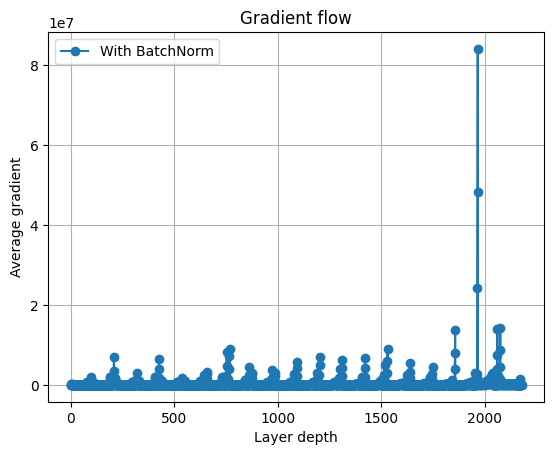

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(layer_idx_bn, avg_grads_bn, label="With BatchNorm", marker="o")
ax.set_xlabel("Layer depth")
ax.set_ylabel("Average gradient")
ax.set_title("Gradient flow")
ax.grid(True)
ax.legend()
plt.show()

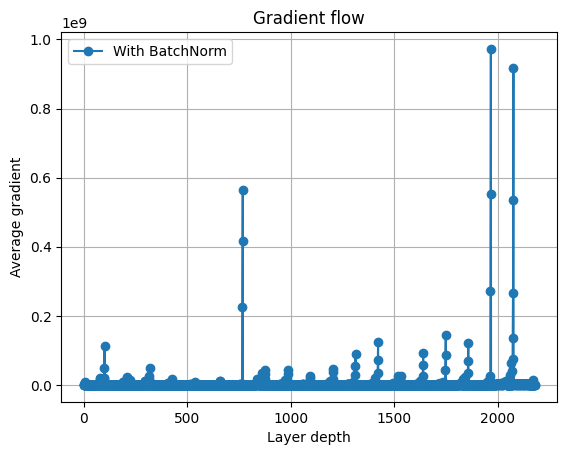

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(layer_idx_bn, avg_grads_bn, label="With BatchNorm", marker="o")
ax.set_xlabel("Layer depth")
ax.set_ylabel("Average gradient")
ax.set_title("Gradient flow")
ax.grid(True)
ax.legend()
plt.show()

In [15]:
v = motor_split_log(batch['body_rotors'])
k = 'log_body_rotors'
v_flat = kingdon_flatten(v)
v_norm = flat_normalize(v_flat, k)
print(f"{k}: mean {v_norm.mean().item():.6f}, std {v_norm.std().item():.6f}")
print(f"{k}: mean {v_flat.mean().item():.6f}, std {v_flat.std().item():.6f}")

log_body_rotors: mean 0.094111, std 9.818488
log_body_rotors: mean 0.004135, std 0.689064


In [3]:
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(k, v.shape)

log_velocity_root_translator_0 torch.Size([3, 1, 1, 4])
log_body_rotors_0 torch.Size([3, 1, 21, 4])
acceleration_body_rotors torch.Size([4, 38, 21, 4])
floor_0 torch.Size([4, 1, 1, 4])
root_motor torch.Size([8, 40, 1, 4])
log_acceleration_root_translator torch.Size([3, 38, 1, 4])
log_acceleration_root_rotor torch.Size([3, 38, 1, 4])
acceleration_root_motor torch.Size([8, 38, 1, 4])
velocity_root_motor torch.Size([8, 39, 1, 4])
log_acceleration_body_rotors torch.Size([3, 38, 21, 4])
body_rotors torch.Size([4, 40, 21, 4])
log_velocity_body_rotors_0 torch.Size([3, 1, 21, 4])
chained_body_rotors torch.Size([8, 40, 21, 4])
velocity_body_rotors torch.Size([4, 39, 21, 4])
log_velocity_root_rotor_0 torch.Size([3, 1, 1, 4])


In [1]:
import torch
torch.cuda.empty_cache()

In [ ]:
kinematic_child_parent

NameError: name 'kinematic_child_parent' is not defined